In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  

from pathlib import Path

OUTPUT = Path('output')

sns.set_theme(style='whitegrid')

## Utils here

In [2]:
def save_fig(name, fig_extension='pdf'):
    path = OUTPUT / f'{name}.{fig_extension}'
    plt.savefig(path, format=fig_extension)


def flat_mean(series):
    n = len(series)

    total = 0
    for x in series:
        total += x
    return total / n


def flat_variance(series):
    n = len(series)
    m = flat_mean(series)

    sq_diff = 0
    for x in series:
        sq_diff += (x - m) ** 2
    return sq_diff / (n - 1)


def expected_val(fi, pmf):
    expected = 0
    for v in range(4):
        expected += fi.iloc[v] * pmf.iloc[v]
    return expected

def variance(fi, pmf, expected):
    var = 0
    for v in range(4):
        var += ((fi.iloc[v] - expected) ** 2) * pmf.iloc[v]
    return var


# Load & Pre-processing

In [3]:
df = pd.read_csv('heart+disease\processed.cleveland.data', header=None,
                 na_values='?')
df.columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df['target'] = (df['target'] > 0).astype(int)

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\kevin\AppData\Local\Temp\ipykernel_26128\927545864.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  df = pd.read_csv('heart+disease\processed.cleveland.data', header=None,


In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [6]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [7]:
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])
print()

In [8]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


# Part One

## Age frequency distribution

In [11]:
max_v = df['age'].max()
min_v = df['age'].min()

amplitude = max_v - min_v

k = 1 + 3.332 * np.log10(56)
k = round(k)

h = amplitude / k
h = round(h)

print(f'amplitude: {amplitude}')
print(f'k:         {k}')
print(f'h:         {h}')

amplitude: 48.0
k:         7
h:         7


In [12]:
intervals = []
start = min_v

for i in range(k):
    end = start + h
    intervals.append((start, end))
    start = end

interval_bastions = []
for i in intervals:
    interval_bastions.append(i[0])
interval_bastions.append(intervals[-1][1])

In [13]:
data = pd.Series(df['age'])

idx = pd.interval_range(start=min_v, end=interval_bastions[-1], periods=k, closed='left')
frequencies_table = pd.DataFrame(index=idx)

In [14]:
counts = pd.cut(data, bins=interval_bastions, right=False).value_counts().sort_index()
frequencies_table['fi'] = counts.values
frequencies_table['fr'] = frequencies_table['fi'] / df['age'].shape[0]
frequencies_table['fraci'] = frequencies_table['fr'].cumsum()
frequencies_table['pmi'] = [interval.mid for interval in frequencies_table.index]

In [15]:
frequencies_table

,fi,fr,fraci,pmi
"[29.0, 36.0)",7,0.023102,0.023102,32.5
"[36.0, 43.0)",29,0.095710,0.118812,39.5
"[43.0, 50.0)",51,0.168317,0.287129,46.5
"[50.0, 57.0)",75,0.247525,0.534653,53.5
"[57.0, 64.0)",90,0.297030,0.831683,60.5
"[64.0, 71.0)",45,0.148515,0.980198,67.5
"[71.0, 78.0)",6,0.019802,1.000000,74.5


In [16]:
mean = flat_mean(df['age'])
var = flat_variance(df['age'])
std = np.sqrt(var)

print(f'mean: {mean:.4f}'
      f'\nvar:  {var:.4f}'
      f'\nstd:  {std:.4f}')

mean: 54.4389
var:  81.6974
std:  9.0387


# Part Two


1. Heatmap: O heatmap serve para nos mostrar as correlações entre as colunas númericas dos nossos dados, a partir dele conseguimos identificar as magnitudes e as direções das correlações,  no heatmap criado podemos ver que as correlações que possuem 1 são correlações perfeitas, os que possuem 0 não possuem relações e os que possuem relação -1 possuem uma relação negativa, sobre a magnitude podemos ver que possuem uma magnitude um pouco baixa devido a ausência de cores masi vibrantes

2. Gráfico de correlação: Esse gráfico é a visuzalição da correlação das colunas age e thalach no qual possuem uma relação linear fraca negativa, com uma linha de tendência mostrando a incidência da correlação

3. histograma de idade: Nessa visualização temos um histograma que mostra a quantidade de pessoas que estão naquelas determinadas classes com base nos bins que foram determinados pela Regra de Sturges na Part One

4. Boxplot de idade por target: Nesse boxplot foi utilizada as colunas target com base na coluna idade, e logo abaixo temos as medias e medianas de cada caso da coluna target (0, 1) com base nas idades 

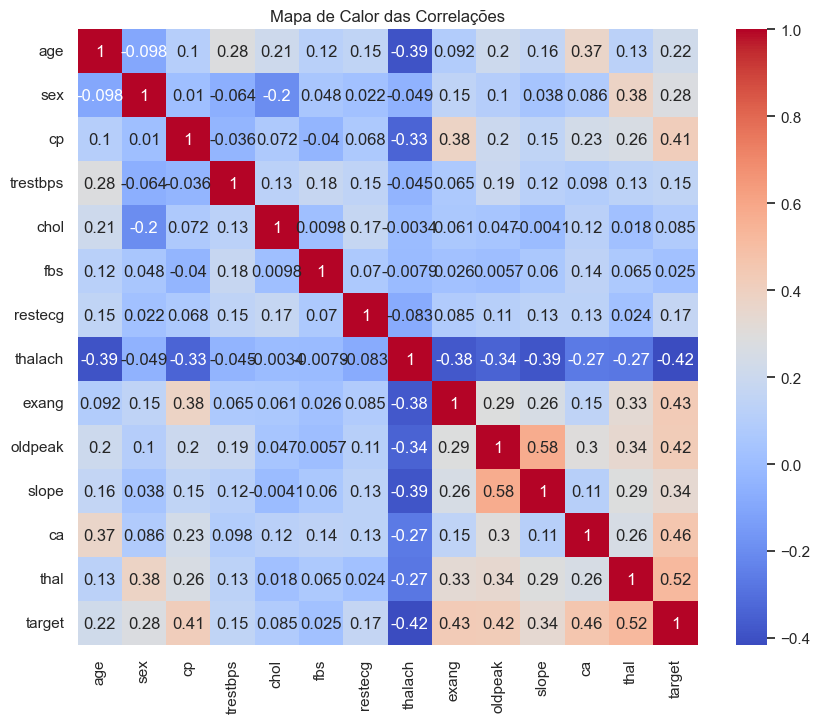

In [17]:
numerical_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de Calor das Correlações')
plt.show()

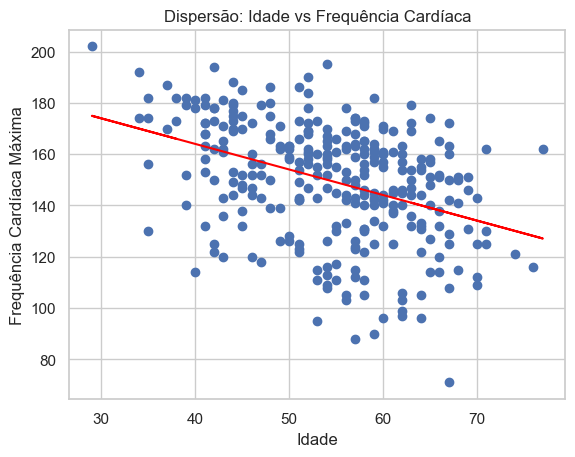

Coeficiente de Correlação Peso x Consumo: -0.39


In [18]:
plt.scatter(df['age'], df['thalach'])
z = np.polyfit(df['age'], df['thalach'], 1)
p = np.poly1d(z)
plt.plot (df['age'], p(df['age']), color='red')
plt.title('Dispersão: Idade vs Frequência Cardíaca')
plt.xlabel('Idade')
plt.ylabel('Frequência Cardíaca Máxima')
plt.grid(True)
plt.show()

correlacao_mpg = df['age'].corr(df['thalach'])
print(f'Coeficiente de Correlação Peso x Consumo: {correlacao_mpg:.2f}')


<Axes: xlabel='age', ylabel='Count'>

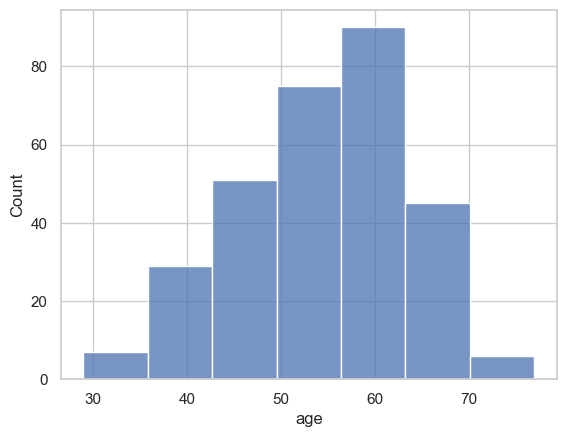

In [19]:
sns.histplot(df['age'], bins=h)

C:\Users\kevin\AppData\Local\Temp\ipykernel_26128\3800042308.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


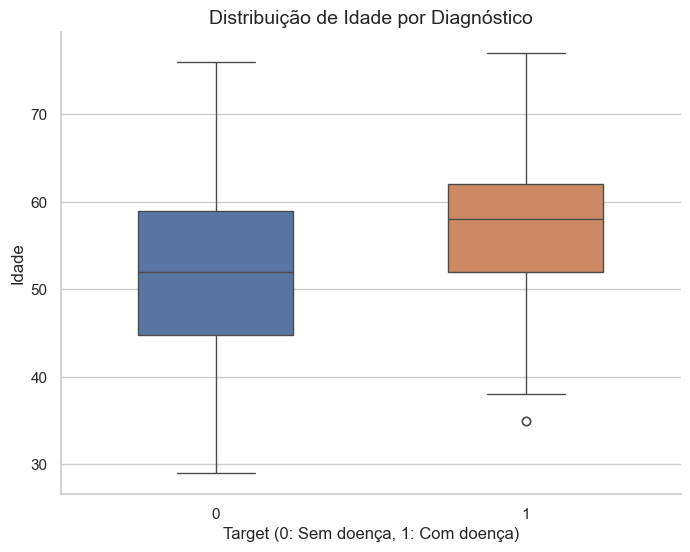

Media(t=0): 52.58536585365854, Mediana(t=0): 52.0
Media(t=1): 56.62589928057554, Mediana(t=1): 58.0


In [20]:
plt.figure(figsize=(8, 6))

age_T0 = df[df["target"] == 0]['age']
age_T1 = df[df["target"] == 1]['age']
media = np.mean(age_T1)
mediana = np.median(age_T1)
media2 = np.mean(age_T0)
mediana2 = np.median(age_T0)

ax = sns.boxplot(
    data=df, 
    x='target', 
    y='age', 
    palette=['#4C72B0', '#DD8452'],
    width=0.5
)
plt.title('Distribuição de Idade por Diagnóstico', fontsize=14)
plt.xlabel('Target (0: Sem doença, 1: Com doença)')
plt.ylabel('Idade')
sns.despine()
plt.show()

print(f"Media(t=0): {media2}, Mediana(t=0): {mediana2}")
print(f"Media(t=1): {media}, Mediana(t=1): {mediana}")

# Part Three

In [21]:
age_bins = interval_bastions
age_labels = [
    f"{int(age_bins[i])}-{int(age_bins[i + 1] - 1)}"
    for i in range(len(age_bins) - 1)
]

df_age_split = pd.DataFrame()
df_age_split['age_band'] = pd.cut(
    df['age'],
    bins=age_bins,
    labels=age_labels,
    right=False,
    include_lowest=True
)
df_age_split['target'] = df.target

fi = df_age_split.groupby('age_band')['target'].sum()
fi

age_band
29-35     2
36-42     6
43-49    18
50-56    29
57-63    60
64-70    23
71-77     1
Name: target, dtype: int64

In [22]:
pmf = fi / fi.sum()
pmf

age_band
29-35    0.014388
36-42    0.043165
43-49    0.129496
50-56    0.208633
57-63    0.431655
64-70    0.165468
71-77    0.007194
Name: target, dtype: float64

In [23]:
cdf = pmf.cumsum()
cdf

age_band
29-35    0.014388
36-42    0.057554
43-49    0.187050
50-56    0.395683
57-63    0.827338
64-70    0.992806
71-77    1.000000
Name: target, dtype: float64

In [24]:
expected = expected_val(fi, pmf)
var = variance(fi, pmf, expected)

print(f'E(Y) = {expected}')
print(f'Var(Y) = {var}')

E(Y) = 8.66906474820144
Var(Y) = 98.4600831316728


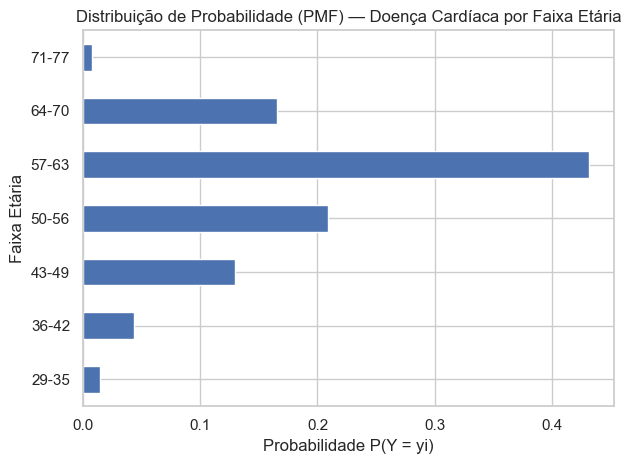

In [25]:
fig, ax = plt.subplots()
pmf.plot.barh(ax=ax)
ax.set_title('Distribuição de Probabilidade (PMF) — Doença Cardíaca por Faixa Etária')
ax.set_xlabel('Probabilidade P(Y = yi)')
ax.set_ylabel('Faixa Etária')
plt.tight_layout()
plt.show()

In [26]:
fi_cumulative = fi.cumsum()
cdf_labels_aculmuladas = cdf.copy()
cdf_labels_aculmuladas.index = fi_cumulative.values
cdf_labels_aculmuladas

2      0.014388
8      0.057554
26     0.187050
55     0.395683
115    0.827338
138    0.992806
139    1.000000
Name: target, dtype: float64

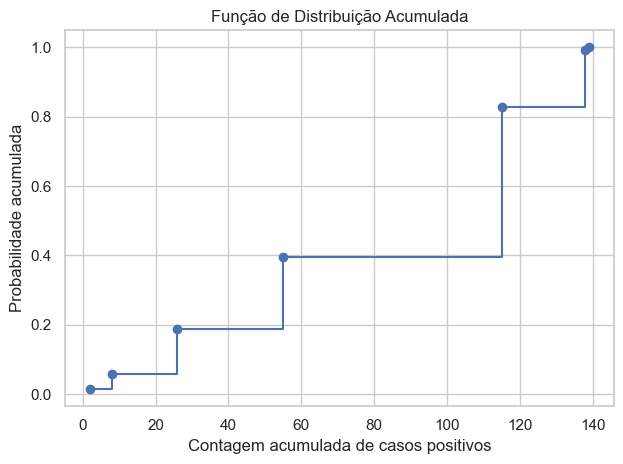

In [27]:
fig, ax = plt.subplots()
cdf_labels_aculmuladas.plot(drawstyle='steps-post', ax=ax, marker='o')
ax.set_title('Função de Distribuição Acumulada')
ax.set_xlabel('Contagem acumulada de casos positivos')
ax.set_ylabel('Probabilidade acumulada')
plt.tight_layout()
plt.show()

### Problema aplicado

60% de chance aproximadamente, do valor de pacientes ser maior que 40

# Part Four

In [28]:
df_contingency = pd.crosstab(df['sex'], [df['target']]) 

df_contingency['total'] = df_contingency.sum(axis=1)
df_contingency.loc['total'] = df_contingency.sum()

df_contingency

target,0,1,total
sex,,,
0.0,72,25,97
1.0,92,114,206
total,164,139,303


In [29]:
from scipy.stats import chi2_contingency
chi2_stat, p_val, dof, ex = chi2_contingency(df_contingency.iloc[:-1, :-1])

print('Frequências esperadas:')
print(ex)

Frequências esperadas:
[[ 52.50165017  44.49834983]
 [111.49834983  94.50165017]]


In [30]:
for alpha in [0.05, 0.10]:
    decisao = "Rejeita H0" if p_val < alpha else "Não rejeita H0"
    print(p_val)
    print(f"α = {alpha}: {decisao}")

2.666712348180942e-06
α = 0.05: Rejeita H0
2.666712348180942e-06
α = 0.1: Rejeita H0


# Part Five

In [31]:
from scipy.stats import pearsonr

corr, p_val = pearsonr(df['age'], df['thalach'])

print(f"Coeficiente de Pearson: {corr:.4f}")
print(f"p-value: {p_val:.4f}")

for alpha in [0.05, 0.10]:
    decisao = "Rejeita H0" if p_val < alpha else "Não rejeita H0"
    print(f"α = {alpha}: {decisao}")

Coeficiente de Pearson: -0.3938
p-value: 0.0000
α = 0.05: Rejeita H0
α = 0.1: Rejeita H0
